In [ ]:
from heart_disease.data.ingestion import load_file
from heart_disease.config import (
    RAW_DATA_DIR,
    FEATURES,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
)
from heart_disease.features.cleaning import (
    replace_invalid_values,
    target_to_binary,
    calculate_missing_data,
)
from heart_disease.visualization.plot import create_plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Objective

> The Objective of this project is to identify patients at high risk of heart disease using routinely collected clinical information. Since missing patient with heart disease is costly, recall and F1-Score will be emphasized over Accuracy

# 2. Dataset Overview

After defining the problem and the project objectives, the next critical step is to develop a comprehensive understanding of the available data, evaluate its quality, and ensure the data used for model training are of high quality, representative, and free from bias as possible.

In [ ]:
df = load_file(RAW_DATA_DIR / "heart_disease_uci.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.describe(include="all")

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


For consistency we will rename the label from `num` to `target`. Furthermore, the original label consists of four labels; however, this project focus solely on predicting the presence or absence of heart disease rather than its severity. Accordingly, we will laterr transform the label from the original 0,1,2,3,4 into binary values 0 and 1, representing negative and positive cases of heart disease, respectively.

In [5]:
df = df.rename(columns={"num": "target"})

In [6]:
df.shape

(920, 16)

This dataset contains 920 rows and 15 features (excluding id and label) which provide information for subsequent model assumption 

# 3. Target Analysis

In [7]:
df["target"].value_counts()

target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [8]:
df = target_to_binary(df)
df["target"].value_counts()

2026-08-16 22:03:51,427 | INFO | heart_disease.features.cleaning | Converting target to binary


target
1    509
0    411
Name: count, dtype: int64

> Based on the output above it seems that the classes were imbalanced, the sample size decrease as severity increases. However, since the objective of this project is to predict of the occurence of heart disease rather than its severity, we conclude that the class distributions is fairly balanced

# 4. Missing Data Analysis

As observed from `df.describe()` output above, the `chol` and `trestbps` feature contains a value of 0, which falls outside the physiologically normal range, as human cholesterol and resting blood sugar levels cannot be that low. Same with `oldpeak` which is representing ST depression induced by exercise relative to rest, plausible range for this features is between zero to about six and negative value is representing ST elevation rather than ST depression. Since from the original documentation the variable is specifically defined as ST depression, negative values are generally considered incosistent with the feature definition. This is presumed to be attributable to measurement error; therefore, we convert these instances to missing data.

In [9]:
df = replace_invalid_values(df, ["chol", "trestbps", "oldpeak"])

2026-08-16 22:03:51,764 | INFO | heart_disease.features.cleaning | Replacing 172 non-positive chol values to nan.
2026-08-16 22:03:51,826 | INFO | heart_disease.features.cleaning | Replacing 1 non-positive trestbps values to nan.
2026-08-16 22:03:51,841 | INFO | heart_disease.features.cleaning | Replacing 382 non-positive oldpeak values to nan.


In [10]:
calculate_missing_data(df)

,Percentage of missing data
ca,66.413043
thal,52.826087
oldpeak,48.260870
slope,33.586957
chol,21.956522
fbs,9.782609
trestbps,6.521739
thalch,5.978261
exang,5.978261
restecg,0.217391


As indicated in the output above, ten columns contain missing values, four of which exhibit missingness exceeding twenty percent of their total entries. Prior to determining whether to drop or impute the missing data, it is necessary to assess whether the missingness is random and whether it correlates with the predicition outcome.

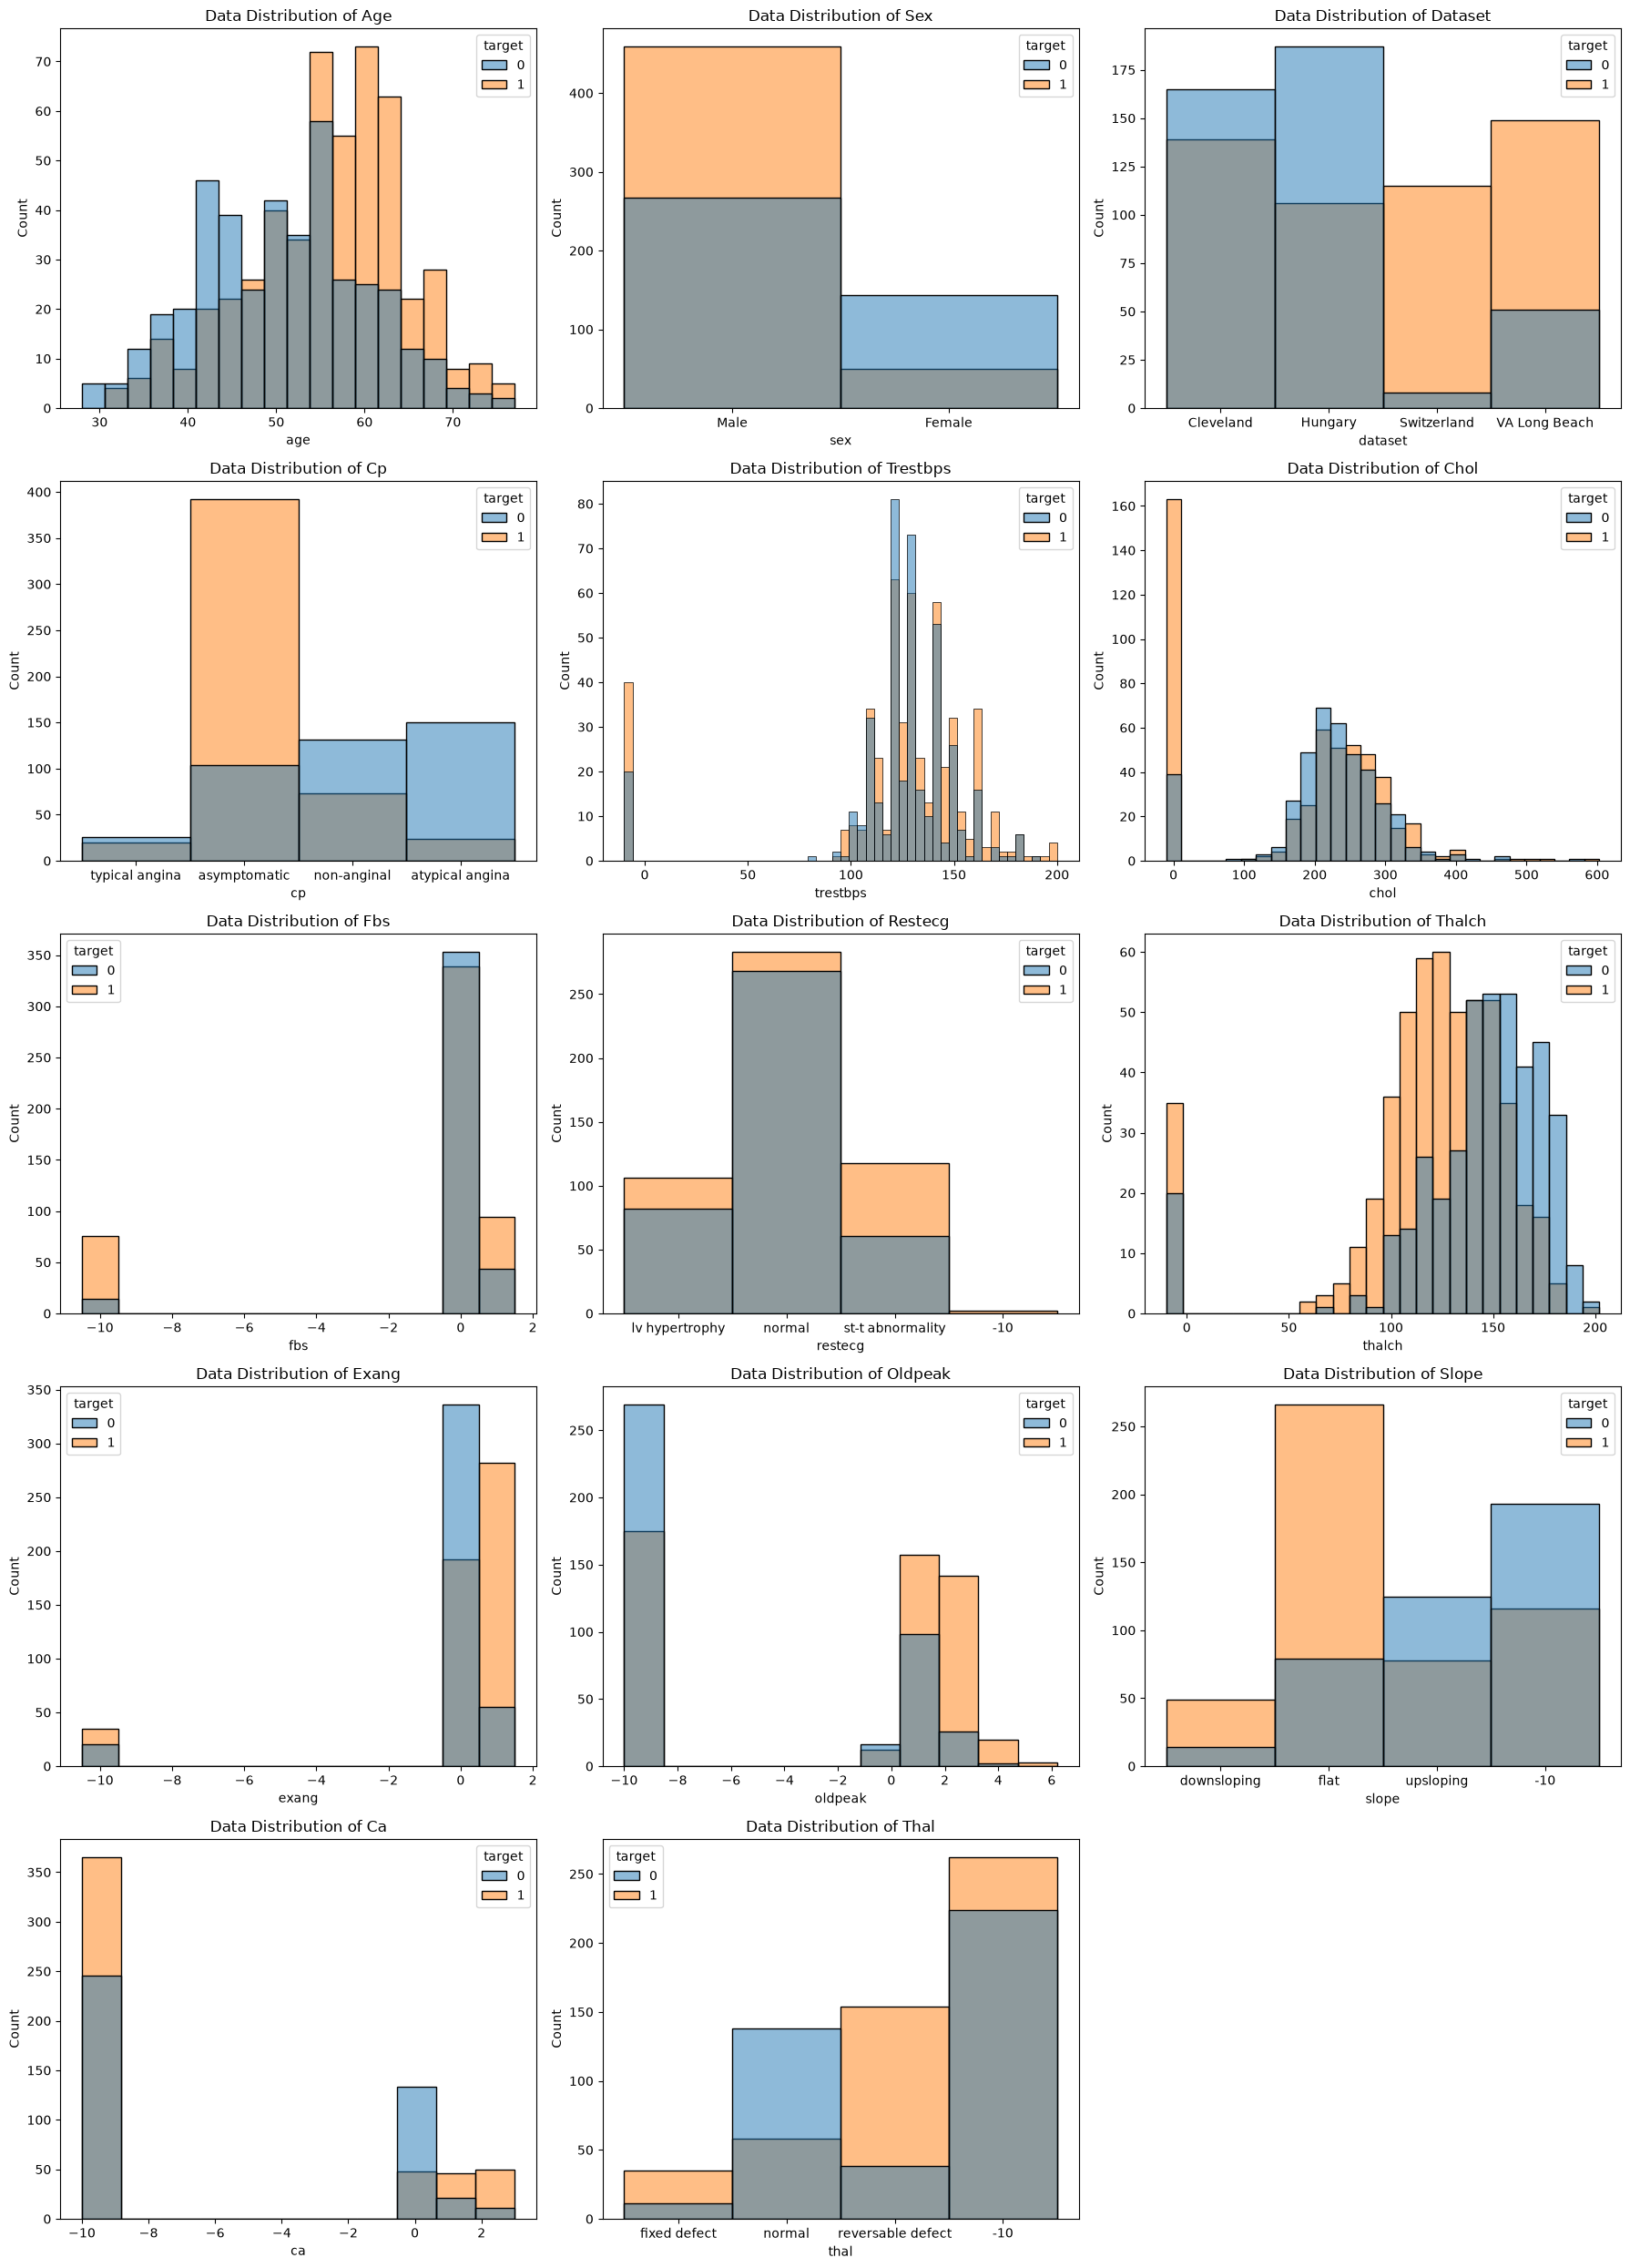

In [11]:
# We want examine the data distribution including missing values using histograms and assess their correlation with the target

df_with_missing = df.copy()
for col in (
    df_with_missing.columns
):  # For visualization purpose, the missing values temporarily encoded as -10
    impute = "-10" if df_with_missing[col].dtype == "object" else -10
    df_with_missing[col] = df_with_missing[col].fillna(impute)

create_plot(
    sns.histplot, df_with_missing, FEATURES, hue="target", title="Data Distribution of"
)

From the chart above we can see the distribution of each features and we can see that missing data in all features is containing higher percentage of positive label which might indicating that missing value is associated with heart disease in patient. One possible explanation is that patients with more severe clinical presentations underwent incomplete testing; however, this hypothesis cannot be verified from the available data and would require knowledge of the data collection process, we need to investigate further about the plausible cause of the missing value to create best imputation strategy

In [12]:
df["has_missing"] = df.isna().any(axis=1)
pd.crosstab(df["has_missing"], df["target"], normalize="index")

target,0,1
has_missing,,
False,0.443350,0.556650
True,0.447699,0.552301


Although an initial inspection suggested a possible association between missingness and the target, the output above shows that both positive and negative groups exhibit similar distributions of missing values. This suggests that missingness is unlikely to be strongly associated with the target variable.

In [13]:
def create_multiple_crosstab(df, columns, normalize=False):
    crosstabs = {}

    for col in columns:
        crosstabs[col] = pd.crosstab(
            df[col],
            df["target"],
            normalize=normalize,
        )

    for col, table in crosstabs.items():
        display(table)


missing_data = pd.DataFrame()
for col in FEATURES:
    missing_data[f"missing_{col}"] = df[col].isna()
missing_data["target"] = df["target"]


create_multiple_crosstab(missing_data, missing_data.columns, normalize="index")

target,0,1
missing_age,,
False,0.446739,0.553261


target,0,1
missing_sex,,
False,0.446739,0.553261


target,0,1
missing_dataset,,
False,0.446739,0.553261


target,0,1
missing_cp,,
False,0.446739,0.553261


target,0,1
missing_trestbps,,
False,0.454651,0.545349
True,0.333333,0.666667


...

target,0,1
missing_oldpeak,,
False,0.298319,0.701681
True,0.605856,0.394144


target,0,1
missing_slope,,
False,0.356792,0.643208
True,0.624595,0.375405


target,0,1
missing_ca,,
False,0.533981,0.466019
True,0.402619,0.597381


target,0,1
missing_thal,,
False,0.430876,0.569124
True,0.460905,0.539095


target,0,1
target,,
0,1.0,0.0
1,0.0,1.0


In [14]:
pd.crosstab(df["dataset"], df["has_missing"], normalize="index")

has_missing,False,True
dataset,,
Cleveland,0.661184,0.338816
Hungary,0.003413,0.996587
Switzerland,0.000000,1.000000
VA Long Beach,0.005000,0.995000


In [15]:
pd.crosstab(
    [df["dataset"], df["has_missing"]], df["target"], normalize="all", margins=True
)

target                            0         1       All
dataset       has_missing                              
Cleveland     False        0.097826  0.120652  0.218478
              True         0.081522  0.030435  0.111957
Hungary       False        0.000000  0.001087  0.001087
              True         0.203261  0.114130  0.317391
Switzerland   True         0.008696  0.125000  0.133696
VA Long Beach False        0.000000  0.001087  0.001087
              True         0.055435  0.160870  0.216304
All                        0.446739  0.553261  1.000000

Based on the output above, dataset from `Switzerland` and `VA Long Beach` have more than 99% of their data missing, at the same time patient in those dataset have significantly higher rate of heart disease but if we look at `Cleveland` and `Hungary` dataset its appear that missing value occur more in the absence of heart disease, therefore we can assume that missing values is not strongly correlated with the presence of heart disease, but rather are more associated with source of the dataset.

In [16]:
pd.crosstab([df["dataset"], df["sex"]], df["has_missing"], normalize="all")

has_missing              False     True 
dataset       sex                       
Cleveland     Female  0.066304  0.039130
              Male    0.152174  0.072826
Hungary       Female  0.000000  0.088043
              Male    0.001087  0.229348
Switzerland   Female  0.000000  0.010870
              Male    0.000000  0.122826
VA Long Beach Female  0.000000  0.006522
              Male    0.001087  0.209783

In [17]:
df.groupby("has_missing")["age"].mean()

has_missing
False    56.147783
True     52.764296
Name: age, dtype: float64

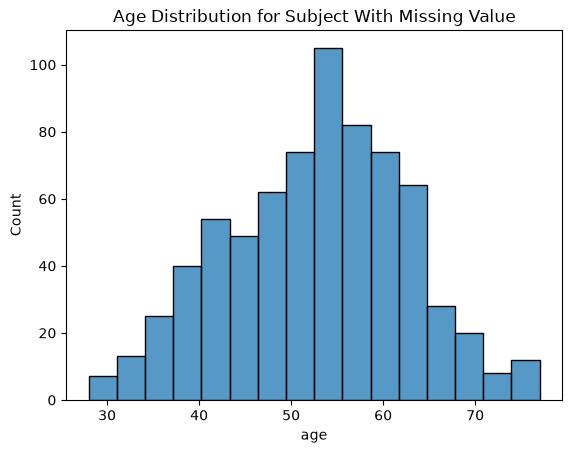

In [ ]:
sns.histplot(df['has_missing']["age"])
plt.title("Age Distribution for Subject With Missing Value")
plt.show()

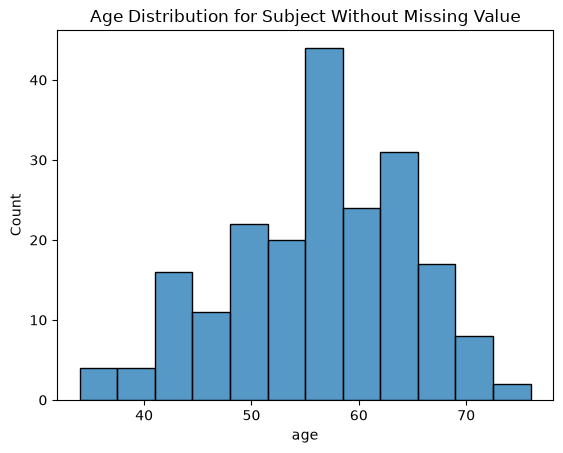

In [ ]:
sns.histplot(df[~df["has_missing"]]["age"])
plt.title("Age Distribution for Subject Without Missing Value")
plt.show()

>Based on the output above, all datasets except `Cleveland` exhibit a substantially higher frequency of missing value among `males` than `females`. However, this pattern is likely attributable to the greater representation of male subjects within these datasets rather than a direct association between missingness and sex. Additionally, missingness does not appear to be related to `age`, as observation with missing and non-missing values show similar distributions and means value. Taken together, these findings suggest that missingness is primarily associated with the datasets source, supporting the plausibility of the `Missing At Random (MAR)` assumption. However, because the underlying data collection process is unknown, the possibility of `Missing Not At Random (MNAR)` mechanism cannot be excluded.

# 5. Numerical Feature Analysis

In [20]:
NUMERIC_FEATURES = list(NUMERIC_FEATURES)
df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.00,77.0
trestbps,860.0,132.286047,18.536175,80.0,120.0,130.0,140.00,200.0
chol,718.0,246.832869,58.527062,85.0,210.0,239.5,276.75,603.0
thalch,865.0,137.545665,25.926276,60.0,120.0,140.0,157.00,202.0
oldpeak,476.0,1.610714,0.950895,0.1,1.0,1.5,2.00,6.2


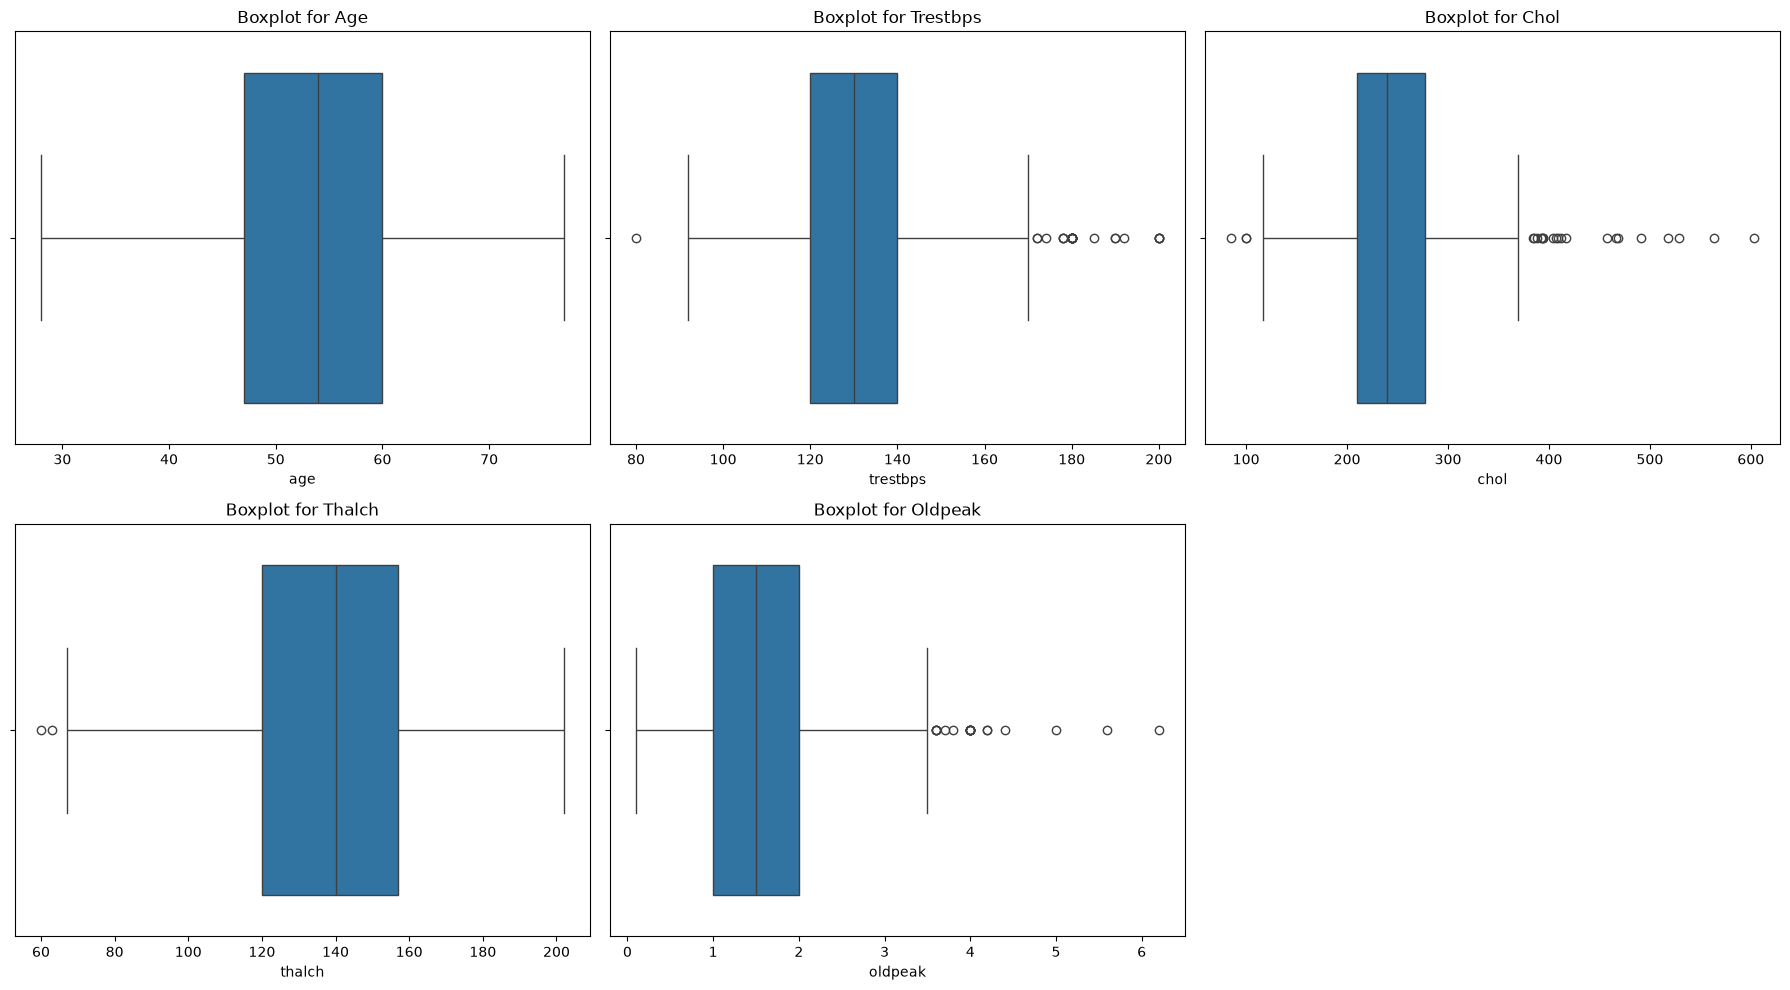

In [21]:
create_plot(sns.boxplot, df, NUMERIC_FEATURES, title="Boxplot for")

Based on the boxplot above we can observe the distributions for every numeric features, given the boxplot it appears that every features except for `age` contain outliers. We need to investigate further about the features to provide insight which lead to better handling strategy for the outliers. For resting blood pressure which is `trestbps` range for this data is fallen between eighty to two hundred mmHg. Altough the boxplot shows there is some outliers, all outliers still fallen in possible pysiologically range for resting blood preassure, dropping the outliers might remove useful signal for the model. Same with Cholesterol `chol`, maximum heart rate `thalch`, and number of major vessel `ca` outliers in these features is still fallen in possible range, therefore dropping the outliers wont be necessary.

In [22]:
df.groupby("target")[NUMERIC_FEATURES].mean()

,age,trestbps,chol,thalch,oldpeak
target,,,,,
0,50.547445,129.913043,240.158602,148.800512,1.160563
1,55.903733,134.264392,254.008671,128.261603,1.802096


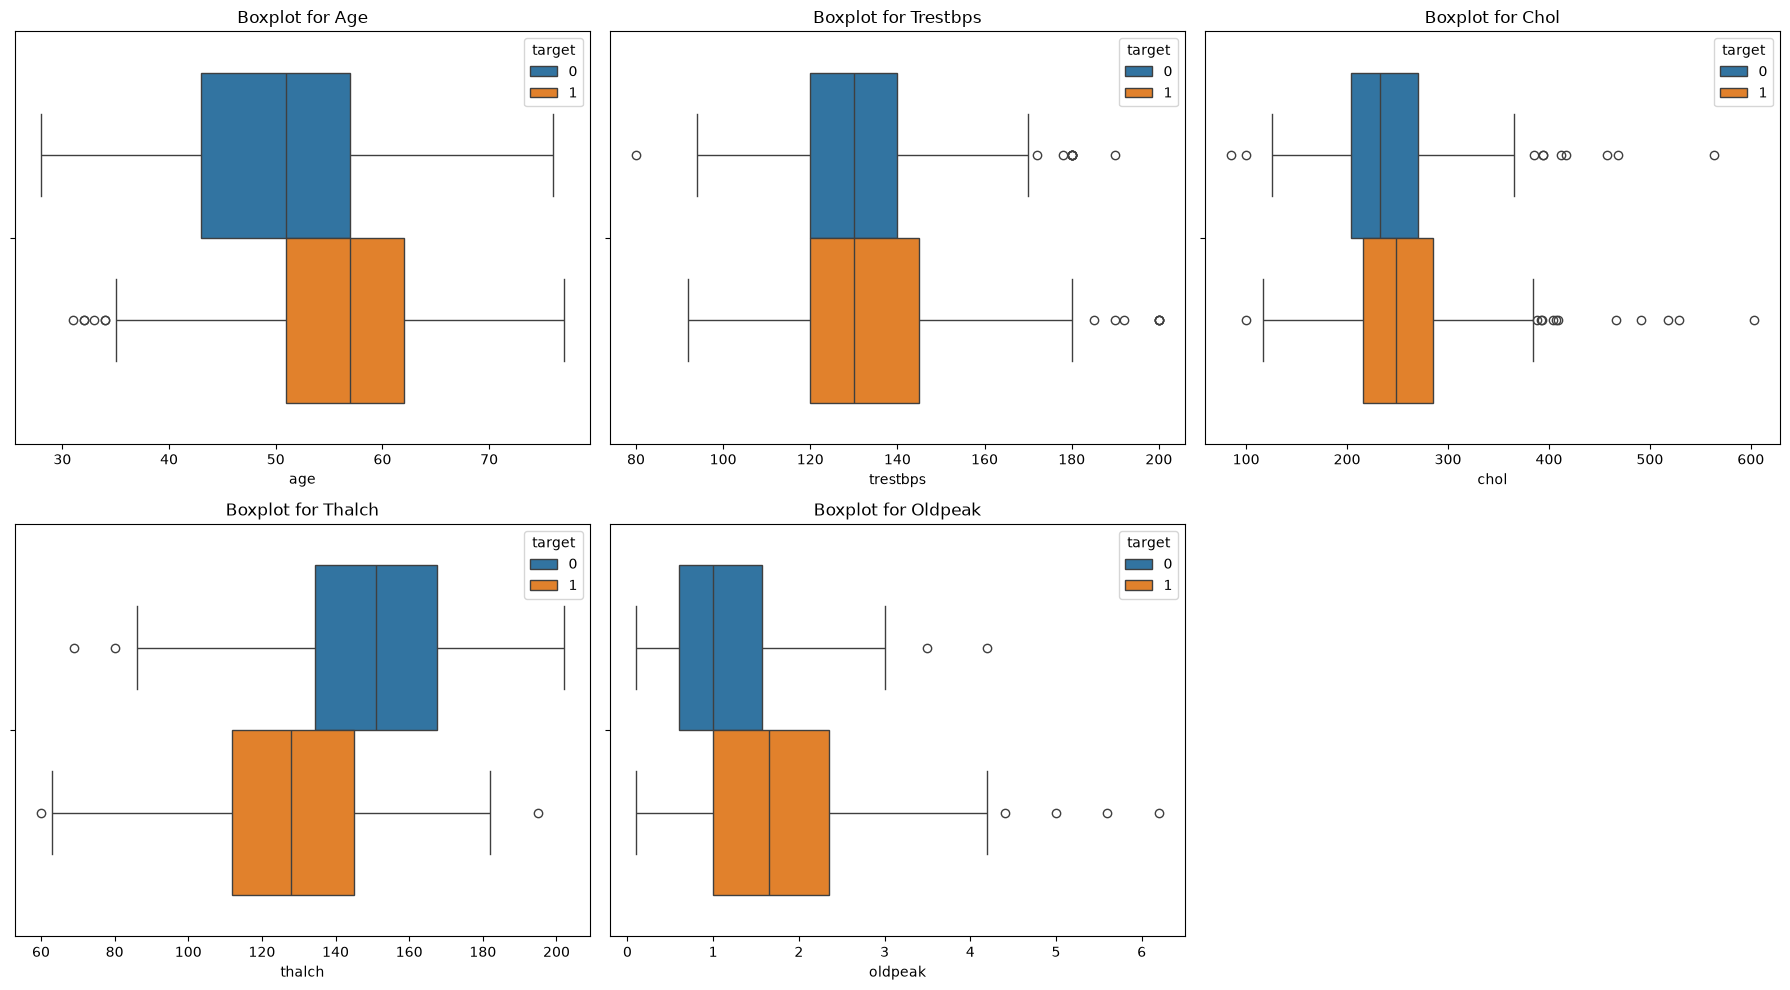

In [23]:
create_plot(sns.boxplot, df, NUMERIC_FEATURES, title="Boxplot for", hue="target")

In [24]:
df[NUMERIC_FEATURES + ["target"]].corr()["target"].sort_values()

thalch     -0.394503
trestbps    0.116959
chol        0.118327
age         0.282700
oldpeak     0.308996
target      1.000000
Name: target, dtype: float64

As we can see from the output above that positive group exhibits higher median values of `age` and `oldpeak`, while exhibiting lower median value of `thalch` than the negative group. These potential relationship may provide useful insight for subsequent feature selection and engineering. Meanwhile, `trestbps` and `chol` show substantial overlap between the positive and negative groups, suggesting that these features may have limited predictive value individually but could still provide useful information through interaction with other features.

# 6. Categorical Feature Analyisis

In [25]:
CATEGORICAL_FEATURES = list(CATEGORICAL_FEATURES)
for column in CATEGORICAL_FEATURES:
    print(f"\n=== {column} ===")
    print(df[column].value_counts(dropna=False))


=== sex ===
sex
Male      726
Female    194
Name: count, dtype: int64

=== cp ===
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

=== fbs ===
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

=== restecg ===
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

=== exang ===
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

=== slope ===
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

=== ca ===
ca
NaN    611
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

=== thal ===
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


2026-08-16 22:04:39,123 | INFO | heart_disease.features.cleaning | Converting target to binary


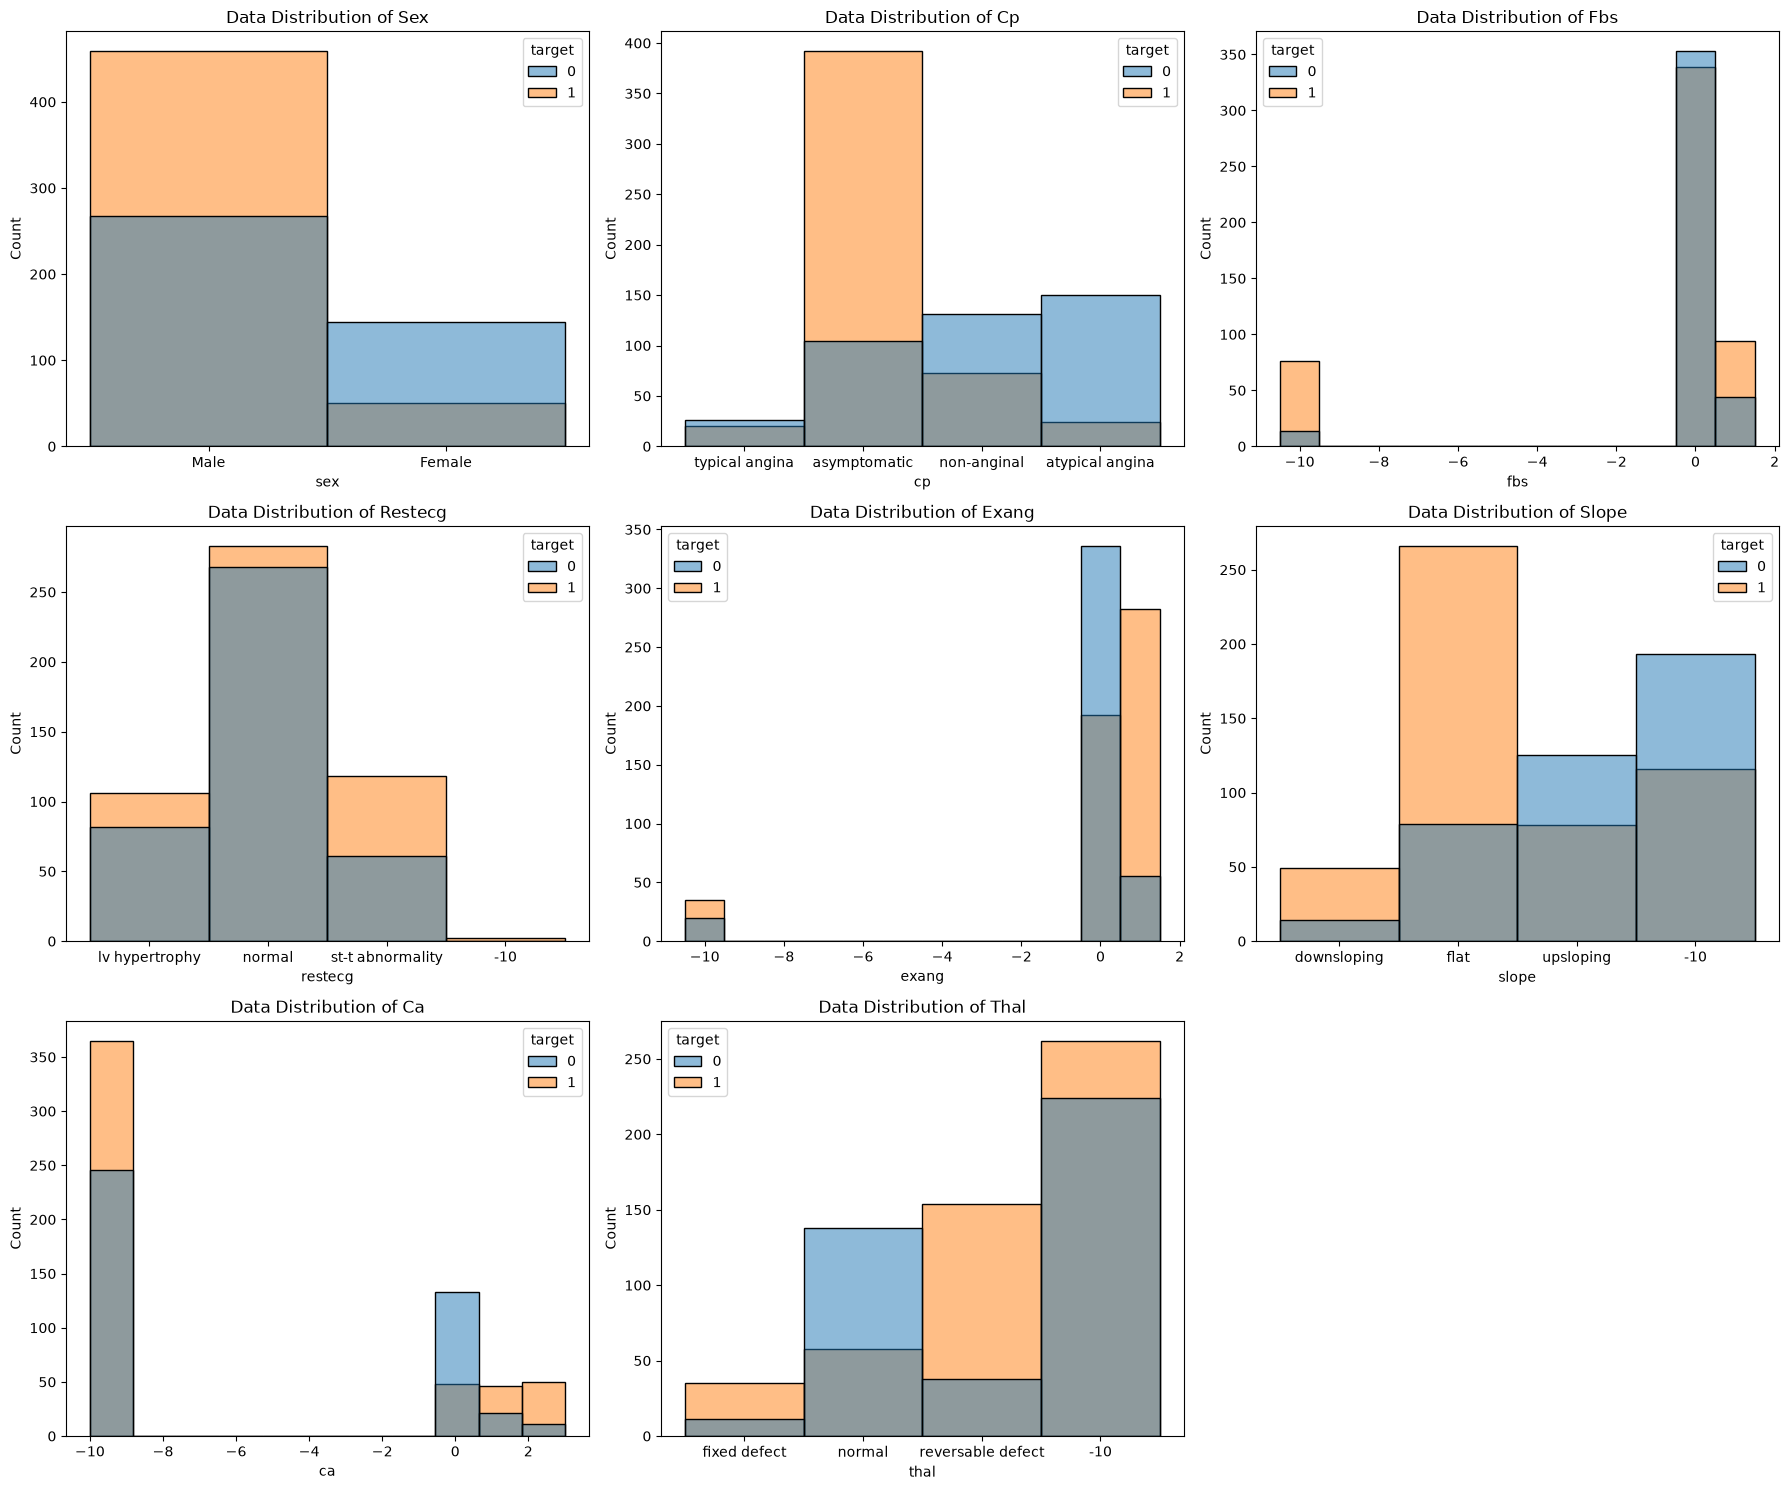

In [26]:
df_with_missing = target_to_binary(df_with_missing)
create_plot(
    sns.histplot,
    df_with_missing,
    CATEGORICAL_FEATURES,
    hue="target",
    title="Data Distribution of",
)

Histograms above show that in each feeatures contain category that potentially act as a strong predictor like `male` patient in `sex` features that exhibit more percentage of positive case than `female` who exhibit more percentage of negative case. This insight combining with domain knowledge can provide effective feature engineering strategy.

In [27]:
create_multiple_crosstab(df, CATEGORICAL_FEATURES, normalize="index")

target,0,1
sex,,
Female,0.742268,0.257732
Male,0.367769,0.632231


target,0,1
cp,,
asymptomatic,0.209677,0.790323
atypical angina,0.862069,0.137931
non-anginal,0.642157,0.357843
typical angina,0.565217,0.434783


target,0,1
fbs,,
False,0.510116,0.489884
True,0.318841,0.681159


target,0,1
restecg,,
lv hypertrophy,0.436170,0.563830
normal,0.486388,0.513612
st-t abnormality,0.340782,0.659218


target,0,1
exang,,
False,0.636364,0.363636
True,0.163205,0.836795


target,0,1
slope,,
downsloping,0.222222,0.777778
flat,0.228986,0.771014
upsloping,0.615764,0.384236


target,0,1
ca,,
0.0,0.734807,0.265193
1.0,0.313433,0.686567
2.0,0.195122,0.804878
3.0,0.150000,0.850000


target,0,1
thal,,
fixed defect,0.239130,0.760870
normal,0.704082,0.295918
reversable defect,0.197917,0.802083


# 7. Key Findings

> 1. The dataset is aggregated from four sources: `Cleveland`, `Hungary`, `Switzerland`, and `VA Long Beach`.
> 2. All source except `Cleveland` contain substantial amounts missing data.
> 3. The target variable is roughly balanced.
> 4. Several features, including `ca`, `thal`, `oldpeak`, `slope`, and `chol` contain 66%, 53%, 48%, 34%, 23% missing values respectively.
> 5. Three features, namely `chol`, `trestbps`, and `oldpeak` contain zero values that are considered clinically implausib;e and may be the result of measurement or data-entry errors.
> 6. Missingness appears to be associated with source of dataset. MAR assumption is plausible.
> 7. Several features, including `age`, `sex`, `thalch`, `cp`, and `slope`, show indication of an association with the target variable.
> 8. The numerical features have substantially different value ranges.


# 8. Implication for Preprocessing

> 1. Investigate whether missingness should be represented explicitly.
> 2. Convert impossible numerical values to NaN.
> 3. Evaluate appropriate imputation strategies based on the underlying missingness mecahnism.
> 4. Compare models using F1-score rather than accuracy alone to ensure a more robust evaluation.
> 5. Evaluate scaling strategy for numerical features based on model selection